In [1]:
# --! include root folder into PYTHONPATH ---------------------------------!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

In [2]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import kind
import utils_data
import utils_plot

In [3]:
# --!--------------------------------------------------------------------------
# --! load trained models

model = torch.load('../../models/baselines/odmd_kind_sim.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=50, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=250, bias=True)
          (1): Identity()
        )
      )
    )
    (fun_prune): Linear(in_features=6, out_features=3, bias=False)
    (mod_mean): Linear(in_features=3, out_features=3, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=24, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=63, bias=True)

Parameter containing:
tensor([[-0.0060, -0.8289,  0.3731],
        [ 0.8356, -0.0606, -0.3372],
        [-0.3547,  0.3033, -0.0562]])


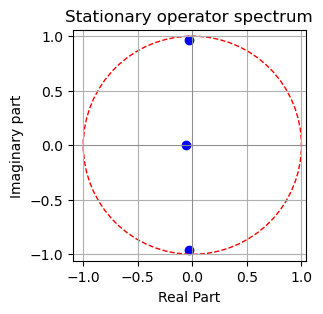

In [4]:
# --!--------------------------------------------------------------------------!
# --! visualize stationary operator eigenvalues

with torch.no_grad():
    utils_plot.plot_eigs(model)

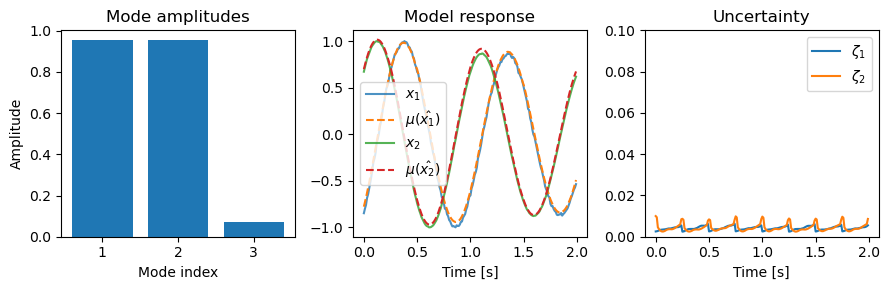

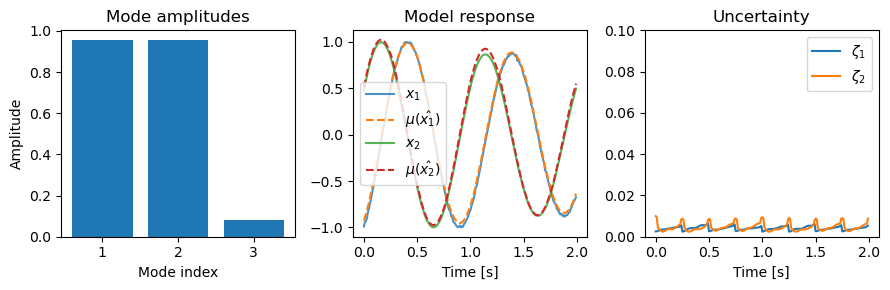

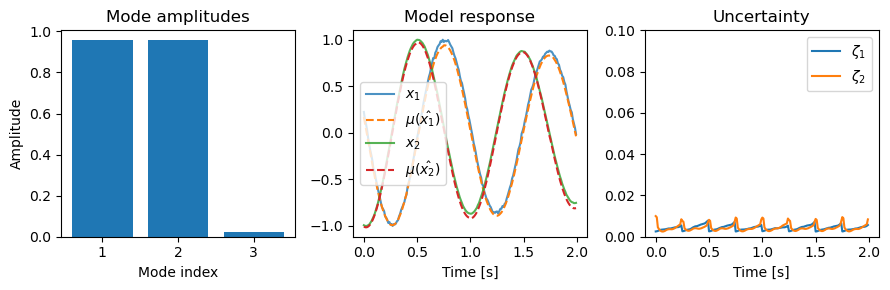

In [5]:
# --!--------------------------------------------------------------------------!
# --! analyze the contribution of stationary operator eigenvalues

datadir            = '../../data/baselines/train_sim_stat'
timeseries_nsample = 200

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

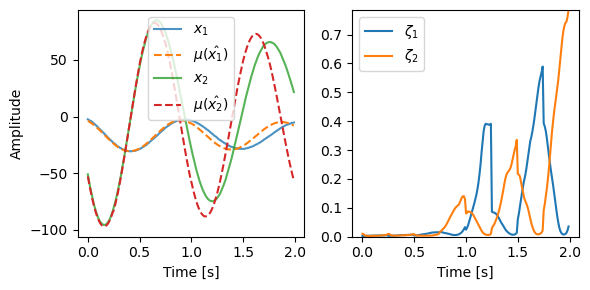

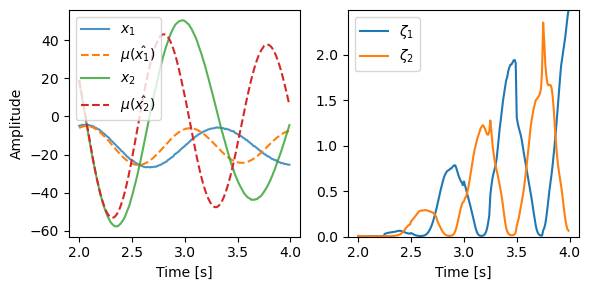

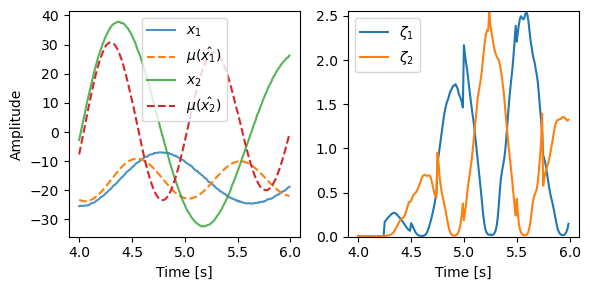

In [6]:
# --!--------------------------------------------------------------------------
# --! evaluate a stationary model

with torch.no_grad():
    datadir            = '../../data/baselines/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_stationary(model, datadir, timeseries_nsample, datasaved=False)

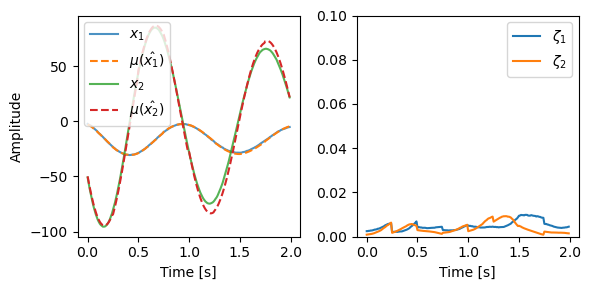

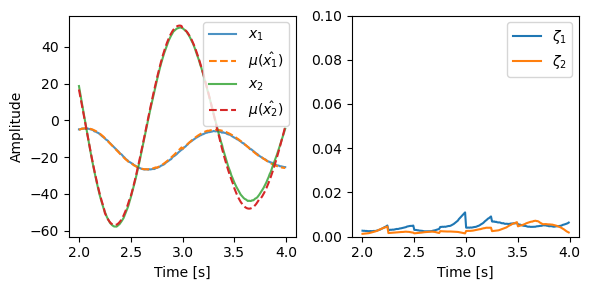

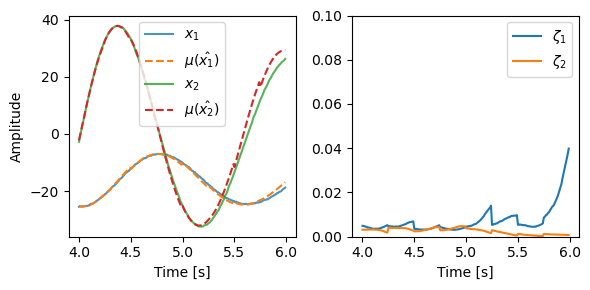

In [7]:
# --!--------------------------------------------------------------------------
# --! evaluate a transient model

with torch.no_grad():
    datadir            = '../../data/baselines/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_transient(model, datadir, timeseries_nsample, datasaved=False)

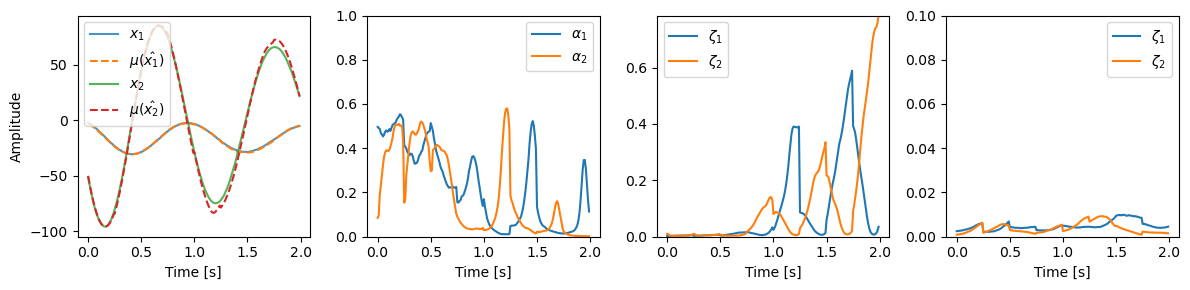

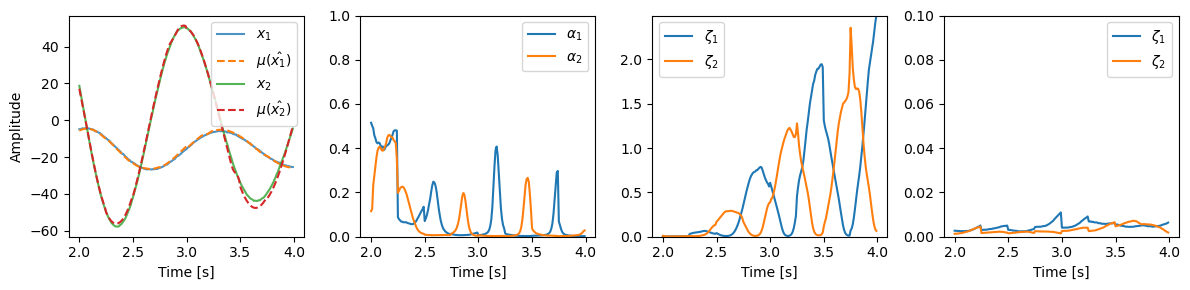

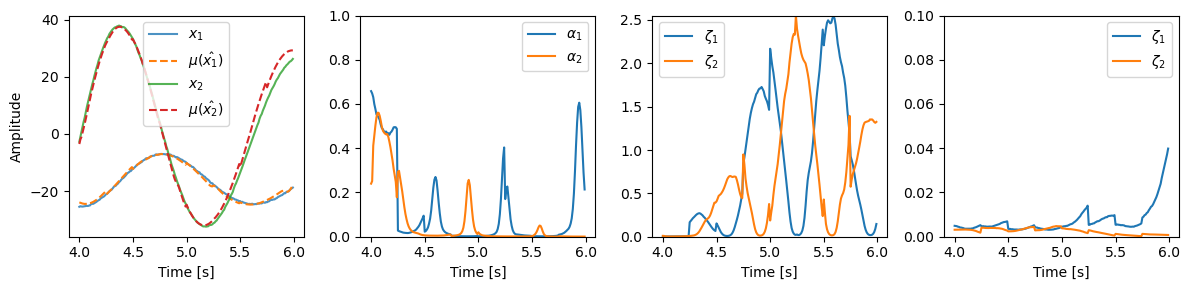

In [8]:
# --!--------------------------------------------------------------------------
# --! test alpha blending

with torch.no_grad():
    datadir            = '../../data/baselines/test_sim'
    timeseries_nsample = 200
    utils_plot.plot_blend(model, datadir, timeseries_nsample, datasaved=False)